In [24]:
import sys
sys.path.insert(0, "..")
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.metrics import compute_metrics

LOG_PATH = Path("../log/")

log_files = sorted(LOG_PATH.glob("*.h5"))
for i, f in enumerate(log_files):
    print(f"{i}: {f.name}")

0: 20260415_211418.h5
1: 20260415_211509.h5
2: 20260415_211806.h5
3: 20260415_211923.h5
4: 20260415_212006.h5
5: 20260415_212112.h5
6: 20260415_212124.h5
7: 20260415_212226.h5
8: 20260415_212302.h5
9: 20260415_212620.h5
10: 20260415_213015.h5
11: 20260415_213025.h5


In [25]:
# pick file by index or set path directly
path = log_files[-1]

with h5py.File(path, "r") as f:
    t   = f["t"][:]
    q1  = f["q1"][:]
    q2  = f["q2"][:]
    dq1 = f["dq1"][:]
    dq2 = f["dq2"][:]
    u   = f["u"][:]

q1 = np.arctan2(np.sin(q1), np.cos(q1))
q2 = np.arctan2(np.sin(q2), np.cos(q2))

metrics = compute_metrics(str(path), upright=np.array([np.pi/2, 0.0, 0.0, 0.0]))

print(f"RMS state error:      {metrics['rms_error']:.4f} rad")
print(f"RMS torque:           {metrics['rms_torque']:.4f} Nm")
print(f"Settling time:        {metrics['settling_time_s']:.3f} s")
print(f"Mean solve time:      {metrics['mean_solve_time_ms']:.3f} ms")
print(f"Max solve time:       {metrics['max_solve_time_ms']:.3f} ms")

print(f"Loaded: {path.name}  |  {len(t)} steps  |  duration {t[-1]:.2f}s")

RMS state error:      6.2505 rad
RMS torque:           8.9512 Nm
Settling time:        nan s
Mean solve time:      0.030 ms
Max solve time:       0.722 ms
Loaded: 20260415_213025.h5  |  2501 steps  |  duration 5.00s


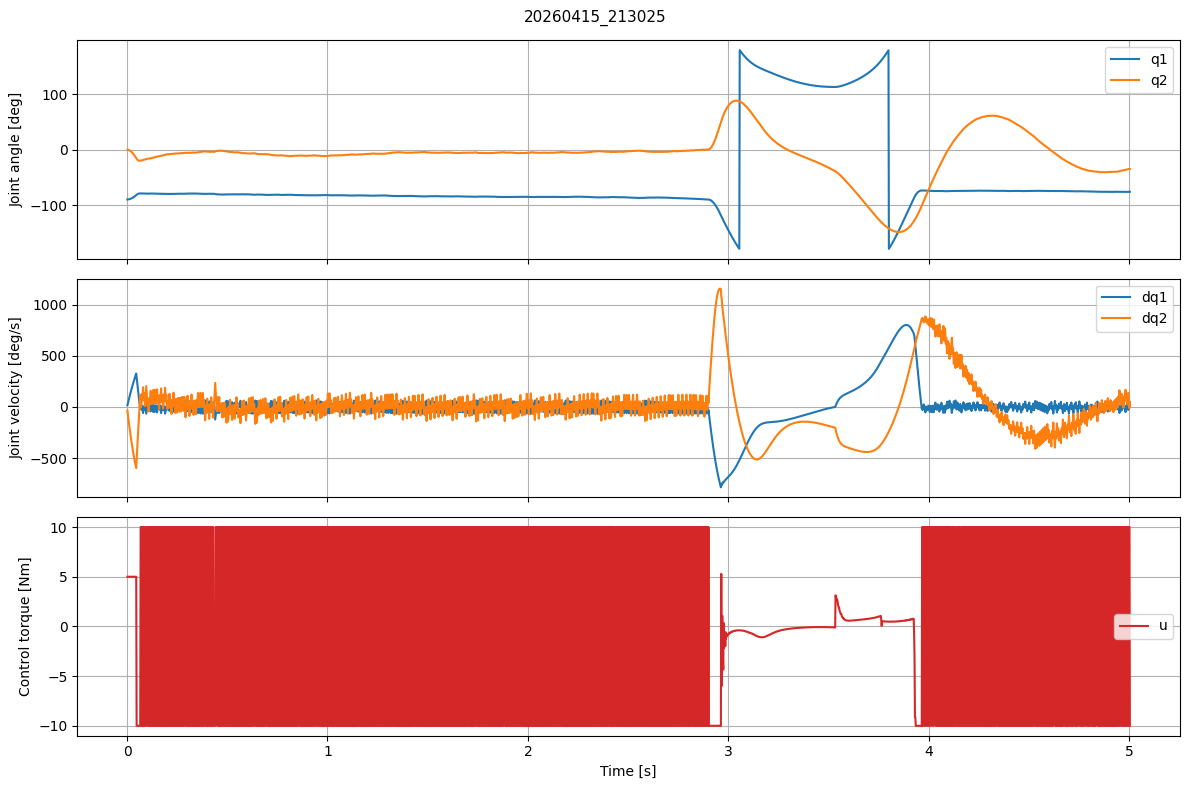

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(path.stem, fontsize=11)

axes[0].plot(t, np.degrees(q1), label="q1")
axes[0].plot(t, np.degrees(q2), label="q2")
axes[0].set_ylabel("Joint angle [deg]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, np.degrees(dq1), label="dq1")
axes[1].plot(t, np.degrees(dq2), label="dq2")
axes[1].set_ylabel("Joint velocity [deg/s]")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t, u, color="tab:red", label="u")
axes[2].set_ylabel("Control torque [Nm]")
axes[2].set_xlabel("Time [s]")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()